Total plotted points: 1746
flag
Unlabeled    582
P1           505
IM           365
P2           294
Name: count, dtype: int64


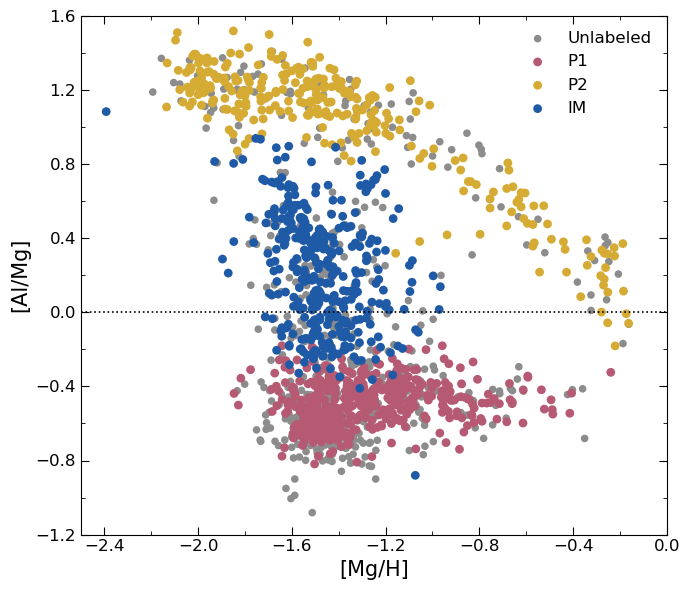

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astropy.io import fits
from matplotlib.ticker import MultipleLocator

members = "~/Downloads/GC_members_VAC-v1_1.fits"
prob_csv = "~/Downloads/201125_wcen_ids_and_probs.csv"

with fits.open(members) as hdul:
    table = hdul[1].data
    cols = {}

    for name in table.columns.names:
        arr = np.array(table[name])
        if arr.ndim == 1:
            if arr.dtype.byteorder == ">":
                arr = arr.byteswap().view(arr.dtype.newbyteorder("="))
            cols[name] = arr

data = pd.DataFrame(cols)
probs = pd.read_csv(prob_csv)

data["GC_NAME"] = data["GC_NAME"].astype(str).str.strip()
data["APOGEE_ID"] = data["APOGEE_ID"].astype(str).str.strip()
probs["APOGEE_ID"] = probs["APOGEE_ID"].astype(str).str.strip()
probs["flag"] = probs["flag"].astype(str).str.strip()

probs = probs.sort_values("prob", ascending=False)
probs = probs.drop_duplicates(subset="APOGEE_ID", keep="first").copy()



for col in ["LOGG", "FE_H", "MG_FE", "AL_FE"]:
    data[col] = pd.to_numeric(data[col], errors="coerce")

omega = data[(data["GC_NAME"] == "NGC5139") & (data["LOGG"] < 3.6)].copy()
omega = omega.drop_duplicates(subset="APOGEE_ID")

omega["MG_H"] = omega["MG_FE"] + omega["FE_H"]
omega["AL_MG"] = omega["AL_FE"] - omega["MG_FE"]

omega = omega.merge(probs[["APOGEE_ID", "flag", "prob"]], on="APOGEE_ID", how="left")
omega["flag"] = omega["flag"].where(omega["flag"].isin(["P1", "IM", "P2"]), "Unlabeled")

plot_df = omega[np.isfinite(omega["MG_H"]) & np.isfinite(omega["AL_MG"])].copy()

print("Total plotted points:", len(plot_df))
print(plot_df["flag"].value_counts())

colors = {
    "Unlabeled": "#8c8c8c",
    "P1": "#b65a73",
    "P2": "#d5ab34",
    "IM": "#1f5aa6"
}

sizes = {
    "Unlabeled": 30,
    "P1": 40,
    "P2": 40,
    "IM": 40
}

fig, ax = plt.subplots(figsize=(7, 6))

for group in ["Unlabeled", "P1", "P2", "IM"]:
    sub = plot_df[plot_df["flag"] == group]
    ax.scatter(
        sub["MG_H"],
        sub["AL_MG"],
        s=sizes[group],
        c=colors[group],
        alpha=1.0,
        edgecolors="none",
        label=group
    )

ax.axhline(0.0, color="black", linestyle=":", linewidth=1.2)

ax.set_xlabel("[Mg/H]", fontsize=15)
ax.set_ylabel("[Al/Mg]", fontsize=15)
ax.set_xlim(-2.5, 0.0)
ax.set_ylim(-1.2, 1.6)

ax.set_xticks(np.arange(-2.4, 0.01, 0.4))
ax.set_yticks(np.arange(-1.2, 1.61, 0.4))
ax.xaxis.set_minor_locator(MultipleLocator(0.2))
ax.yaxis.set_minor_locator(MultipleLocator(0.2))

ax.tick_params(axis="both", which="major", labelsize=12, direction="in", top=True, right=True, length=6)
ax.tick_params(axis="both", which="minor", direction="in", top=True, right=True, length=3)

ax.legend(frameon=False, fontsize=12, loc="upper right")

plt.tight_layout()
plt.show()